# **FACULTAD DE INGENIERÍA - BIOINGENIERÍA**
## **Práctica 5: Introducción al análisis frecuencial de señales**
### Laboratorio Bioseñales y sistemas
- Alejandra Hinestroza Chaparro
- María José Ríos Hurtado

### _Resumen_

### _Marco Teórico_

### _Desarrollo_

**1. Cree una señal que sea la suma de tres componentes sinusoidales con frecuencias de 40, 80 y 160 Hz. Defina la frecuencia de muestreo mínima necesaria para representar la señal, y utilice la frecuencia de muestreo necesaria para representarla apropiadamente. (10%)**

El Teorema de Nyquist dice que para poder representar correctamente una señal sin distorsionarla, la frecuencia de muestreo debe ser al menos el doble de la frecuencia más alta que contiene la señal.

La frecuencia más alta de las tres componentes solicitadas es 160 Hz, entonces:

_**Fs_mínima =** 2 × 160 = 320 Hz_

Pero en la práctica siempre se usa un poco más para tener margen. Se usará _**Fs = 2000 Hz**_, equivalente a 12.5 veces la frecuencia más alta de la señal (160 Hz), lo que garantiza una representación visual suave y cumple ampliamente el criterio de Nyquist con un margen de seguridad adecuado.

Cada sinusoide tiene su propio período:

- **F₁ =** 40 Hz → T₁ = 1/40 = 0.025 s
- **F₂ =** 80 Hz → T₂ = 1/80 = 0.0125 s
- **F₃ =** 160 Hz → T₃ = 1/160 = 0.00625 s

Para que la señal combinada "cierre" un ciclo completo, se usará el período de la componente más lenta (40 Hz), porque las otras dos caben exactamente dentro de él (80 Hz cabe 2 veces, 160 Hz cabe 4 veces).

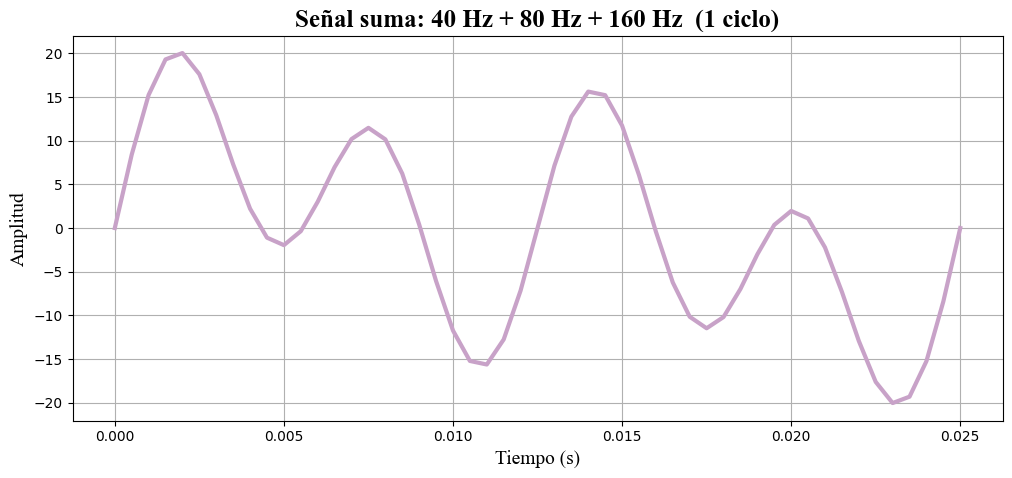

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Frecuencias de cada componente sinusoidal ──
F1 = 40    # Hz
F2 = 80    # Hz
F3 = 160   # Hz

# ── Frecuencia de muestreo ──
# Nyquist exige Fs > 2 * 160 = 320 Hz
# Usamos 2000 Hz para tener buena resolución y números cómodos
Fs = 2000          # Hz
T  = 1 / Fs        # Período de muestreo = 0.001 s (tiempo entre muestras)

# ── Período de la señal completa ──
# La componente más lenta marca el período del conjunto
Tp = 1 / F1        # = 0.025 s (un ciclo completo de 40 Hz)

# ── Vector de tiempo para UN ciclo ──
# np.arange(inicio, fin, paso)
# Empezamos en 0, terminamos en Tp (inclusivo), con pasos de T
t = np.arange(0, Tp + T, T)

# ── Construcción de cada sinusoide ──
# La fórmula es: A * sin(2π * F * t)
# Usamos deferentes amplitudes
x1 = 5*np.sin(2 * np.pi * F1 * t)   # componente de 40 Hz
x2 = 8*np.sin(2 * np.pi * F2 * t)   # componente de 80 Hz
x3 = 12*np.sin(2 * np.pi * F3 * t)   # componente de 160 Hz

# ── Señal total: sumamos las tres ──
x = x1 + x2 + x3

# ── Graficamos ──
plt.figure(figsize=(12, 5))
plt.plot(t, x, linewidth=3, color=(200/255, 162/255, 200/255))
plt.title('Señal suma: 40 Hz + 80 Hz + 160 Hz  (1 ciclo)', fontname = 'Times New Roman', fontsize = 18, fontweight='bold')
plt.xlabel('Tiempo (s)', fontname = 'Times New Roman', fontsize = 14)
plt.ylabel('Amplitud', fontname = 'Times New Roman', fontsize = 14)
plt.grid(True)
plt.show()

**4.2 Calcule la transformada de Fourier de la señal y grafique el espectro de frecuencia. Identifique en el espectro las frecuencias que componen la señal (trabaje con 10 periodos de la señal). (10%)**



Número de muestras en 10 ciclos: 501


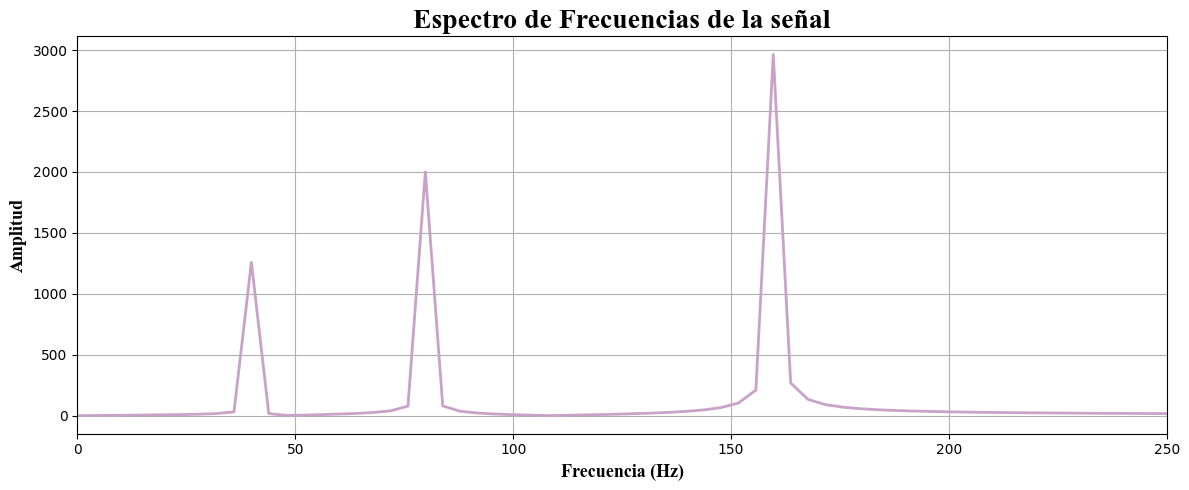

In [3]:
# ── PASO 1: Crear la señal con 10 periodos ──
# Antes teníamos 1 ciclo (duración = Tp = 0.025 s)
# Ahora queremos 10 ciclos (duración = 10 * Tp = 0.25 s)

t10 = np.arange(0, 10*Tp + T, T)   # vector de tiempo para 10 ciclos

# Recreamos la señal suma pero ahora con 10 ciclos
x10 = (5*np.sin(2 * np.pi * F1 * t10) +
       8*np.sin(2 * np.pi * F2 * t10) +
       12*np.sin(2 * np.pi * F3 * t10))

print(f'Número de muestras en 10 ciclos: {len(t10)}')

# ── PASO 2: Calcular la DFT ──
X10 = np.fft.fft(x10)
# X10 es un vector de números complejos
# Para graficar usamos su MÓDULO (np.abs), que representa la amplitud

N = len(X10)   # número total de puntos de la DFT

# ── PASO 3: Crear el eje de frecuencias ──
# Cada índice k de la DFT corresponde a una frecuencia F = k * Fs / N
F_eje = np.arange(0, N) * Fs / N

# ── PASO 4: Solo graficamos la mitad (hasta Nyquist) ──
# La DFT es simétrica: la segunda mitad es espejo de la primera
# Solo nos interesa de 0 Hz hasta Fs/2 
Nmitad   = int(np.ceil(N / 2))
F_mitad  = F_eje[:Nmitad]
X_mitad  = X10[:Nmitad]

# ── PASO 5: Graficar el espectro ──
plt.figure(figsize=(12, 5))
plt.plot(F_mitad, np.abs(X_mitad), color='#C8A2C8', linewidth=2)
plt.title('Espectro de Frecuencias de la señal',
          fontname='Times New Roman', fontsize=20, fontweight='bold')
plt.xlabel('Frecuencia (Hz)', fontname='Times New Roman', fontsize=13, fontweight='bold')
plt.ylabel('Amplitud',        fontname='Times New Roman', fontsize=13, fontweight='bold')
plt.grid(True)

# Hacemos zoom para ver mejor las frecuencias de interés
plt.xlim(0, 250)   # mostramos solo hasta 250 Hz
plt.tight_layout()
plt.show()

**4.3 Consulte la función que permite realizar el cálculo de la transformada inversa de Fourier. Aplíquelo a la señal anterior. (10%)**

**4.4 ¿Podría decir que las siguientes líneas aplican un filtro? ¿Por qué? (10%)**

### _Análisis de resultados y discusión_

### _Conclusiones_